# Breast cancer data exploration

## Data collection
At this step, we'll first acquire the dataset from the UCI Machine Learning Repository.

In [1]:
from ucimlrepo import fetch_ucirepo

# Fetch dataset
breast_cancer_wisconsin_diagnostic = fetch_ucirepo(id=17)
type(breast_cancer_wisconsin_diagnostic)

ucimlrepo.dotdict.dotdict

In [2]:
X = breast_cancer_wisconsin_diagnostic.data.features # type: ignore
X.head()

,radius1,texture1,perimeter1,area1,smoothness1,compactness1,concavity1,concave_points1,symmetry1,fractal_dimension1,...,radius3,texture3,perimeter3,area3,smoothness3,compactness3,concavity3,concave_points3,symmetry3,fractal_dimension3
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


In [3]:
X.columns

Index(['radius1', 'texture1', 'perimeter1', 'area1', 'smoothness1',
       'compactness1', 'concavity1', 'concave_points1', 'symmetry1',
       'fractal_dimension1', 'radius2', 'texture2', 'perimeter2', 'area2',
       'smoothness2', 'compactness2', 'concavity2', 'concave_points2',
       'symmetry2', 'fractal_dimension2', 'radius3', 'texture3', 'perimeter3',
       'area3', 'smoothness3', 'compactness3', 'concavity3', 'concave_points3',
       'symmetry3', 'fractal_dimension3'],
      dtype='object')

The concepts behind the variables are repeated 3 times (ex. texture1, texture2, texture3). I wonder why. This calls for an investigation.

In [4]:
y = breast_cancer_wisconsin_diagnostic.data.targets # type: ignore
y.Diagnosis.unique()

array(['M', 'B'], dtype=object)

In [5]:
# Unique targets
y.value_counts()

Diagnosis
B            357
M            212
Name: count, dtype: int64

## Data exploration

In [6]:
X.describe()

,radius1,texture1,perimeter1,area1,smoothness1,compactness1,concavity1,concave_points1,symmetry1,fractal_dimension1,...,radius3,texture3,perimeter3,area3,smoothness3,compactness3,concavity3,concave_points3,symmetry3,fractal_dimension3
count,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,...,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000
mean,14.127292,19.289649,91.969033,654.889104,0.096360,0.104341,0.088799,0.048919,0.181162,0.062798,...,16.269190,25.677223,107.261213,880.583128,0.132369,0.254265,0.272188,0.114606,0.290076,0.083946
std,3.524049,4.301036,24.298981,351.914129,0.014064,0.052813,0.079720,0.038803,0.027414,0.007060,...,4.833242,6.146258,33.602542,569.356993,0.022832,0.157336,0.208624,0.065732,0.061867,0.018061
min,6.981000,9.710000,43.790000,143.500000,0.052630,0.019380,0.000000,0.000000,0.106000,0.049960,...,7.930000,12.020000,50.410000,185.200000,0.071170,0.027290,0.000000,0.000000,0.156500,0.055040
25%,11.700000,16.170000,75.170000,420.300000,0.086370,0.064920,0.029560,0.020310,0.161900,0.057700,...,13.010000,21.080000,84.110000,515.300000,0.116600,0.147200,0.114500,0.064930,0.250400,0.071460
50%,13.370000,18.840000,86.240000,551.100000,0.095870,0.092630,0.061540,0.033500,0.179200,0.061540,...,14.970000,25.410000,97.660000,686.500000,0.131300,0.211900,0.226700,0.099930,0.282200,0.080040
75%,15.780000,21.800000,104.100000,782.700000,0.105300,0.130400,0.130700,0.074000,0.195700,0.066120,...,18.790000,29.720000,125.400000,1084.000000,0.146000,0.339100,0.382900,0.161400,0.317900,0.092080
max,28.110000,39.280000,188.500000,2501.000000,0.163400,0.345400,0.426800,0.201200,0.304000,0.097440,...,36.040000,49.540000,251.200000,4254.000000,0.222600,1.058000,1.252000,0.291000,0.663800,0.207500


Some features have very different scales. For instance, `perimeter1` has a mean of 91.96 while `area1` has a mean of 654.88. Therefore, scaling is necessary during training.

### Data visualization

In [7]:
# Dimensionality reduction
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
X_2d = pca.fit_transform(X)
X_2d[:5]

array([[1160.1425737 , -293.91754364],
       [1269.12244319,   15.63018184],
       [ 995.79388896,   39.15674324],
       [-407.18080253,  -67.38031982],
       [ 930.34118015,  189.34074158]])

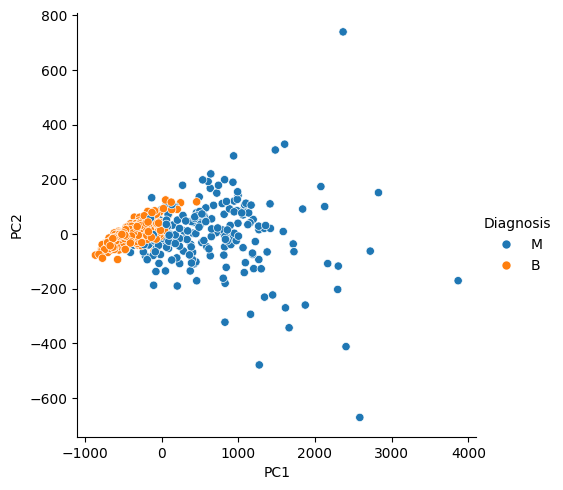

In [8]:
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt

breast_cancer_2d = pd.concat([pd.DataFrame(X_2d, columns=["PC1", "PC2"]), y], axis=1)
sns.relplot(breast_cancer_2d, x="PC1", y="PC2", hue="Diagnosis")
plt.show()

<Axes: xlabel='Diagnosis', ylabel='count'>

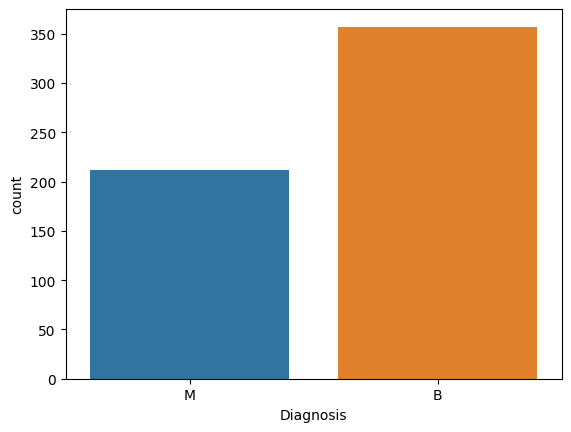

In [9]:
# Target values proportions
sns.countplot(y, x="Diagnosis", hue="Diagnosis")

There is a class imbalance between benign and malignant cases that needs to be accounted for as well.

Thus, `accuracy`, `precision` and `recall` will be used as evaluation metrics.

In [10]:
# Finding out the correlation between the features
corr = X.corr()
corr.shape

(30, 30)

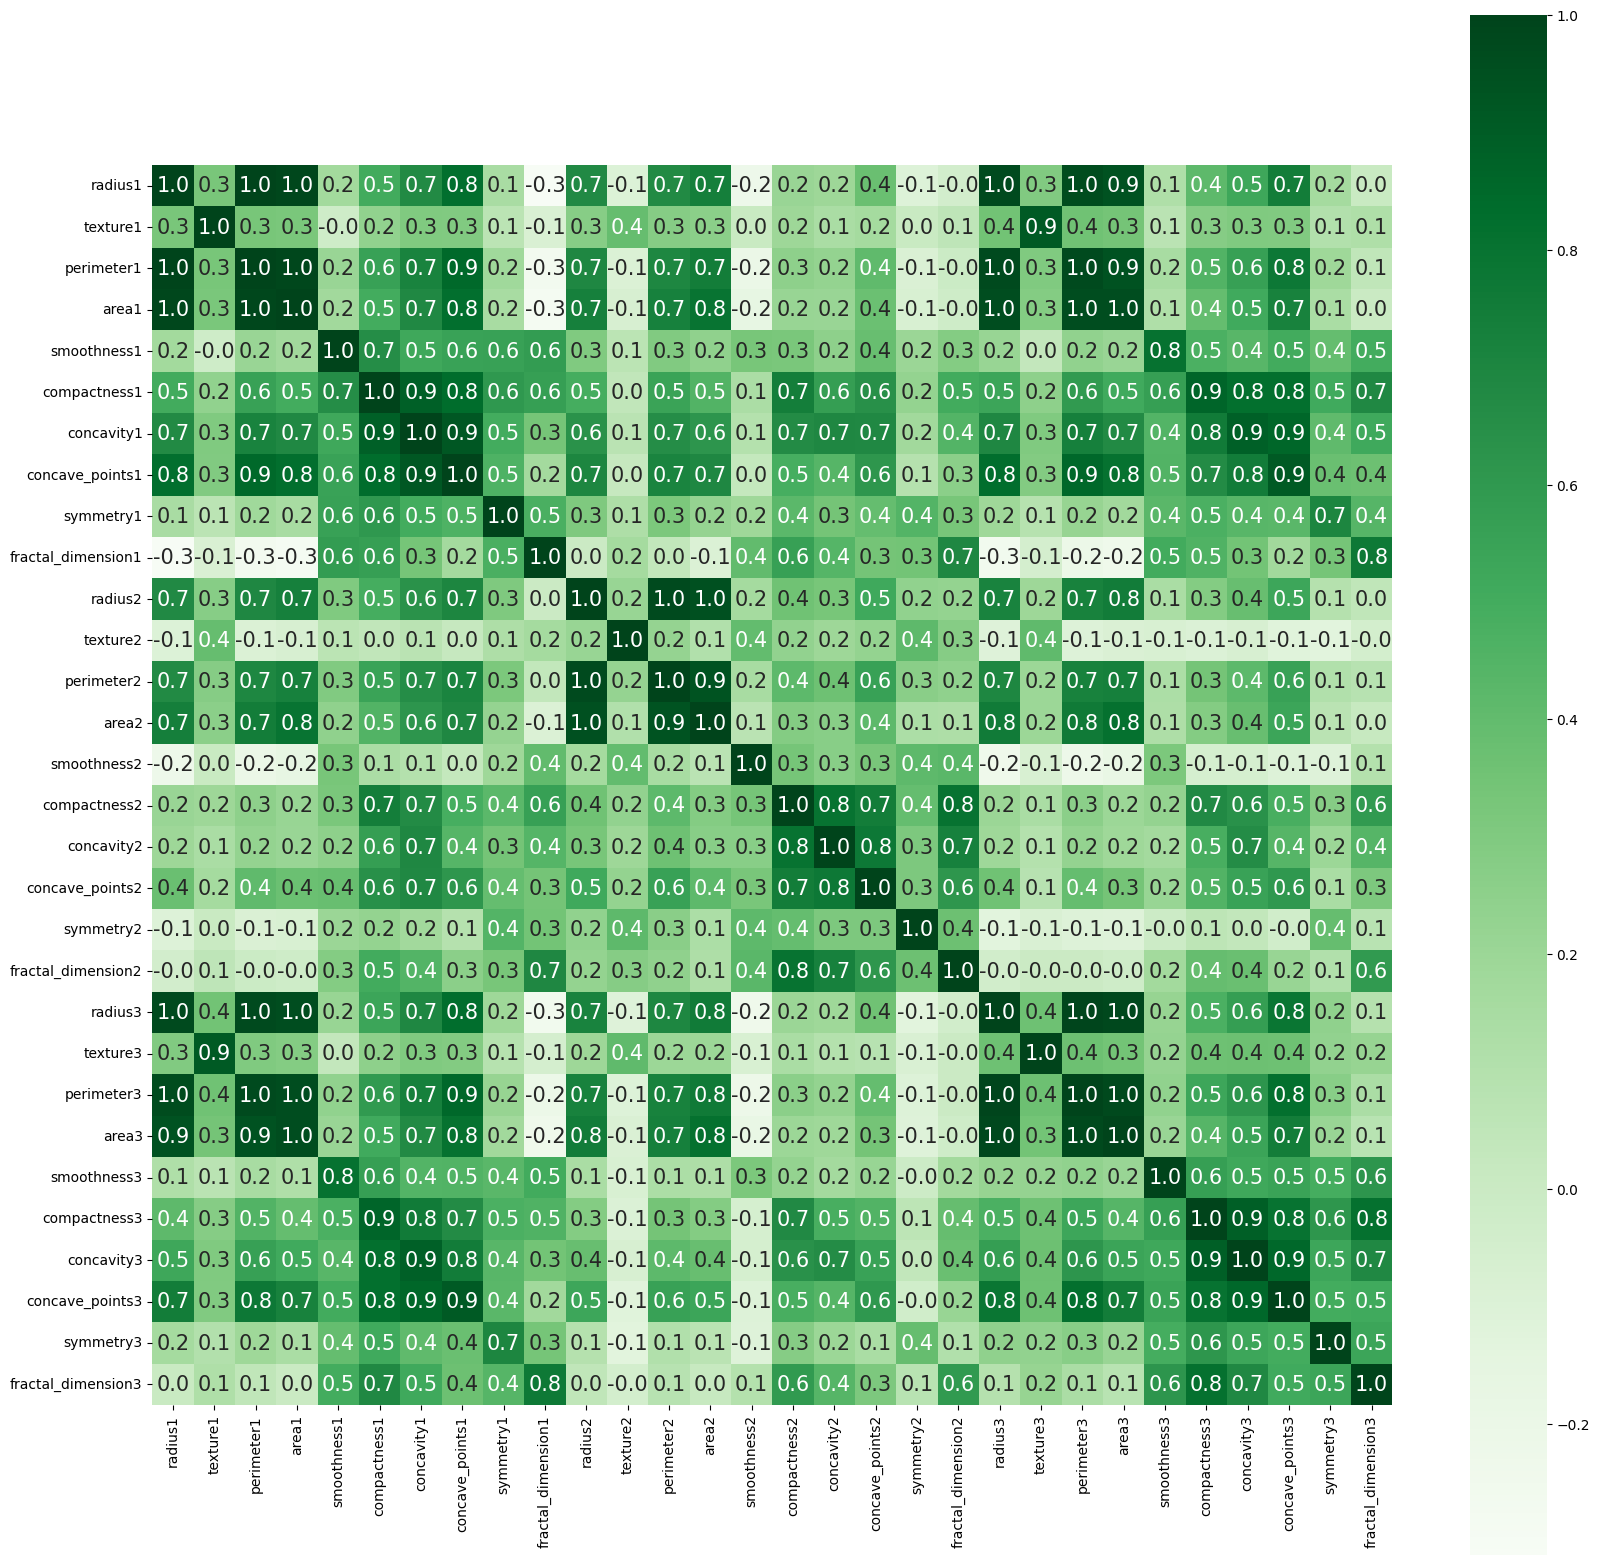

In [11]:
# Plotting the heatmap of correlation between features
plt.figure(figsize=(20, 20))
sns.heatmap(corr, cbar=True, square=True, fmt=".1f", annot=True, annot_kws={"size": 15}, cmap="Greens")
plt.show()

First of all, we can observe that `radius_1` (average cell radius) is strongly correlated with the following averages:
- `perimeter_1`: 1.0
- `area_1`: 1.0
- `concavity_1`: 0.7
- `concave_points1`: 0.8

With the following standard errors:
- `radius_2`: 0.7
- `perimeter_2`: 0.7
- `area_2`: 0.7

And with the following _worsts_ (average of the three largest or most severe values):
- `radius_3`: 1.0
- `perimeter_3`: 1.0
- `area_3`: 0.9
- `concave_points3`: 0.7

- There are many other highly correlated variables. The problem with multicollinearity is that it undermines the significance of independent variables. We can fix it by removing the highly correlated predictors
- For instance, `radius_1` has a correlation of 1 with `perimeter_1` and `area_1` columns. This is because the 3 columns essentially contain the same information, which is the physical size of the observation (the cell). Therefore, we should only pick ONE of the three columns when we go into further analysis
- Another place where multicollinearity is apparent is between the "mean" columns (ending with 1) and the "worst" columns (ending with 3). For instance, the `radius_1` column has a correlation of 1 with the `radius_3` column.
- Also, there is multicollinearity between attributes compactness, concavity, and concave points. So we can choose just ONE out of these. We can go for compactness

In [12]:
# Dropping highly correlated columns

# First, drop all "worst" columns
cols = [
    'radius3', 'texture3', 'perimeter3',
       'area3', 'smoothness3', 'compactness3', 'concavity3', 'concave_points3',
       'symmetry3', 'fractal_dimension3'
]
X = X.drop(cols, axis=1)

# Then, drop all columns related to the "perimeter" and "area" attributes
cols = [
    "perimeter1", 
    "perimeter2",
    "area1",
    "area2"
]
X = X.drop(cols, axis=1)

# Lastly, drop all columns related to the "concavity" and "concave points" attributes
cols = [
    "concavity1",
    "concavity2",
    "concave_points1",
    "concave_points2"
]
X = X.drop(cols, axis=1)

X.columns

Index(['radius1', 'texture1', 'smoothness1', 'compactness1', 'symmetry1',
       'fractal_dimension1', 'radius2', 'texture2', 'smoothness2',
       'compactness2', 'symmetry2', 'fractal_dimension2'],
      dtype='object')

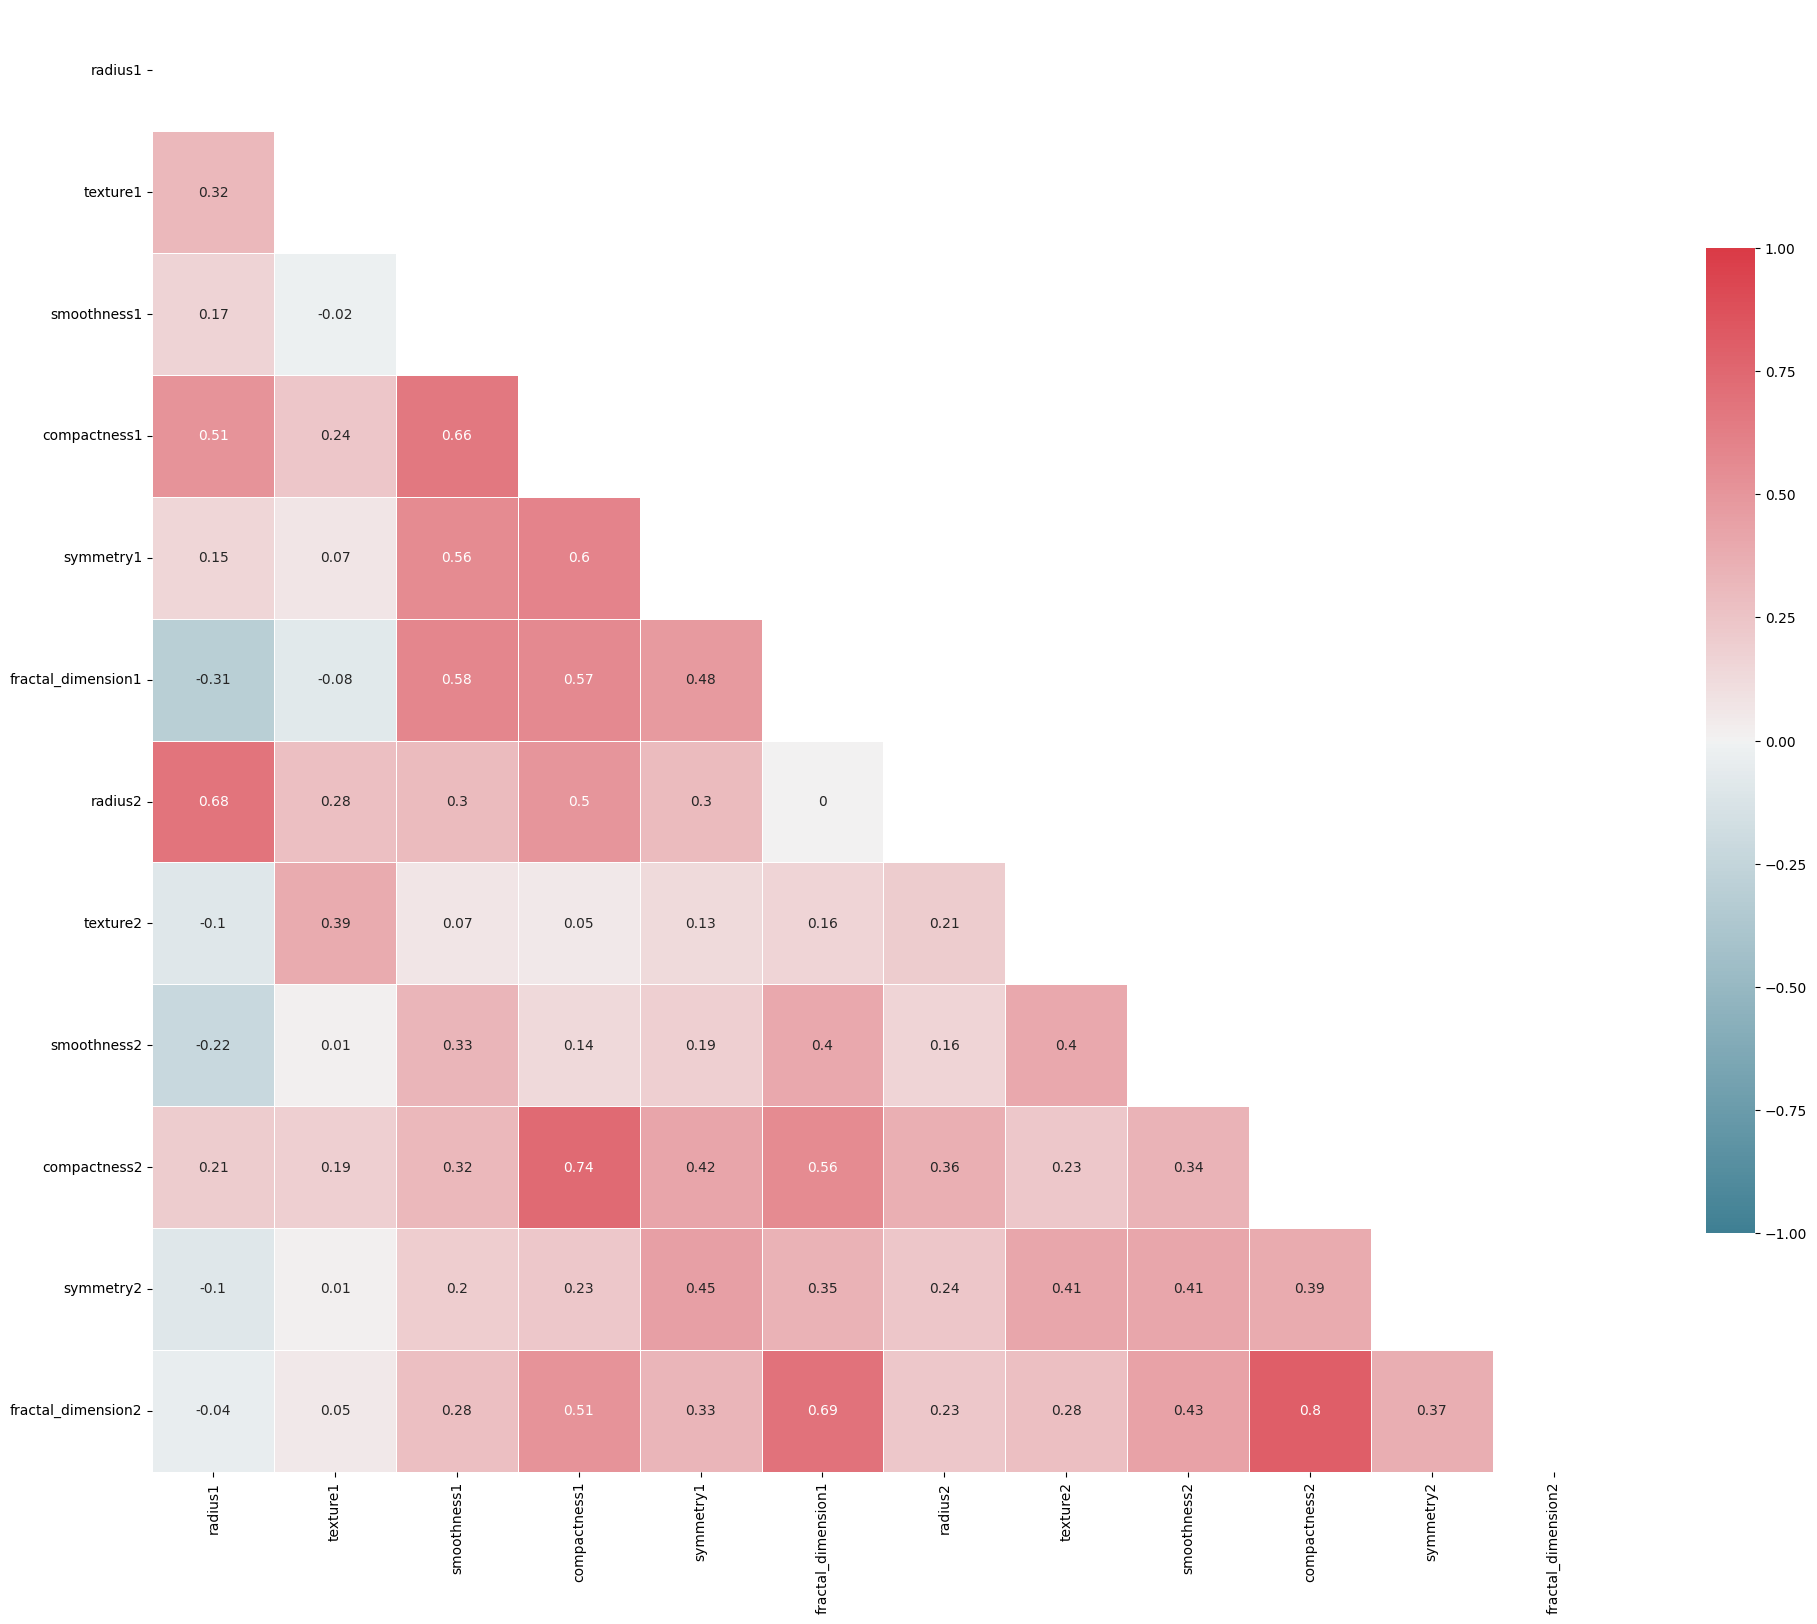

In [13]:
import numpy as np

corr = X.corr().round(2)

# Define custom color map
cmap = sns.diverging_palette(220, 10, as_cmap=True)

mask = np.zeros_like(corr, dtype=np.bool)
mask[np.triu_indices_from(mask)] = True

f, ax = plt.subplots(figsize=(20, 20))
sns.heatmap(corr, mask=mask, cmap=cmap, vmin=-1, vmax=1, center=0, square=True, linewidths=.5, cbar_kws={"shrink": .5}, annot=True)
plt.tight_layout()